In [1]:
from __future__ import annotations

import chromadb
import numpy as np
import pandas as pd
from pathlib import Path


In [2]:
pd.set_option('display.max_columns', None)

# Load from chroma_db

In [3]:
def load_chroma(chroma_path, collection_name=None):
    """Load Chroma persistent DB from ``chroma_path`` and return all points as a DataFrame.

    Parameters
    ----------
    chroma_path : str or Path
        Directory used with ``chromadb.PersistentClient``.
    collection_name : str, optional
        Collection to read. If omitted and exactly one collection exists in the DB,
        that collection is used. If omitted and several exist, a ``ValueError`` lists them.

    Returns columns: ``id``, ``document``, ``embedding``, and ``meta_*`` from metadata.
    """
    path = Path(chroma_path).expanduser().resolve()
    if not path.is_dir():
        raise FileNotFoundError(f"Chroma path is not a directory: {path}")

    client = chromadb.PersistentClient(path=str(path))
    existing = sorted({c.name for c in client.list_collections()}, key=str.lower)

    if not existing:
        raise ValueError(
            f"No collections in {path!s}. Run ingest_bank_feedback first, or check the path "
            f"(notebook cwd + relative path may not point at your real persist folder)."
        )

    if collection_name is None:
        if len(existing) == 1:
            collection_name = existing[0]
        else:
            raise ValueError(
                "Pass collection_name=... One of: " + ", ".join(existing)
            )
    elif collection_name not in existing:
        raise ValueError(
            f"Collection {collection_name!r} not found. Available: {existing}"
        )

    col = client.get_collection(collection_name)

    def _docs_as_list(raw, n_rows):
        if raw is None:
            return [None] * n_rows
        if isinstance(raw, np.ndarray):
            raw = raw.tolist()
        if len(raw) != n_rows:
            raise ValueError(f"documents length {len(raw)} != ids length {n_rows}")
        return list(raw)

    def _embeddings_as_list(raw, n_rows):
        """Chroma often returns a (n, dim) float ndarray; pandas needs one vector per row (object column)."""
        if raw is None:
            return [None] * n_rows
        if isinstance(raw, np.ndarray):
            if raw.ndim == 2 and raw.shape[0] == n_rows:
                return [raw[i].astype(float, copy=False).tolist() for i in range(n_rows)]
            raise ValueError(f"Unexpected embeddings ndarray shape {raw.shape} for n={n_rows}")
        out = []
        for row in raw:
            if row is None:
                out.append(None)
            elif isinstance(row, np.ndarray):
                out.append(row.astype(float, copy=False).tolist())
            else:
                out.append(list(row))
        if len(out) != n_rows:
            raise ValueError(f"embeddings length {len(out)} != ids length {n_rows}")
        return out

    include = ["documents", "embeddings", "metadatas"]
    batch_size = 10_000
    frames = []
    offset = 0
    while True:
        batch = col.get(include=include, limit=batch_size, offset=offset)
        ids = batch.get("ids") or []
        if not ids:
            break
        n = len(ids)
        docs = _docs_as_list(batch.get("documents"), n)
        embs = _embeddings_as_list(batch.get("embeddings"), n)
        df = pd.DataFrame({"id": ids, "document": docs, "embedding": embs})
        metas = batch.get("metadatas") or [None] * n
        meta_df = pd.json_normalize(metas)
        meta_df.columns = [f"meta_{c}" for c in meta_df.columns]
        df = pd.concat([df.reset_index(drop=True), meta_df.reset_index(drop=True)], axis=1)
        frames.append(df)
        offset += n
        if n < batch_size:
            break

    if not frames:
        return pd.DataFrame(columns=["id", "document", "embedding"])

    return pd.concat(frames, ignore_index=True)

In [4]:
# Chroma persist folder: adjust if your kernel cwd is not ``vector-db-writer/notebook``.
# Option A — run Jupyter with cwd = ``notebook/``:
_chroma = (Path.cwd() / ".." / "data" / "vector-db" / "chroma-db").resolve()
# Option B — absolute path (reliable):
# _chroma = Path(r"F:\datascience\dsa-agent\vector-db-writer\data\vector-db")

print("Chroma path:", _chroma, "| exists:", _chroma.is_dir())
df = load_chroma(_chroma)  # if one collection; else load_chroma(_chroma, collection_name="bank_feedback")

Chroma path: F:\datascience\dsa-agent\vector-db-writer\data\vector-db\chroma-db | exists: True


In [5]:
df.head()

,id,document,embedding,meta_submission_type,meta_ticket_number,meta_language,meta_channel,meta_subject,meta_assigned_queue,meta_customer_ref,meta_status,meta_record_type,meta_created_at,meta_generator_version,meta_model,meta_branch_code,meta_synthetic,meta_region,meta_has_attachments,meta_updated_at,meta_source_file,meta_product_bucket
0,BK-2025-00000077,I visited the BR-BALI-003 branch today and had...,"[-0.034575458616018295, 0.0003996578452643007,...",standard_feedback_form,BK-2025-00000077,en,branch_counter,Exceptional service at the counter today,,SYN-CUST-B02-U012-16347958,resolved,bank_complaint_raw,2025-01-01T00:02:30+07:00,0.1.0,gemini-flash-lite-latest,BR-BALI-003,True,BALI_NUSA,False,2025-01-01T19:47:48+07:00,BR-BALI-003.jsonl,account
1,BK-2025-00000078,I am having persistent trouble logging into th...,"[0.0008665235945954919, 0.026163926348090172, ...",standard_feedback_form,BK-2025-00000078,en,mobile_app,Mobile app login issues,RETAIL_CARE,SYN-CUST-B02-U027-D8C772B1,closed,bank_complaint_raw,2025-01-01T22:40:09+07:00,0.1.0,gemini-flash-lite-latest,BR-BALI-003,True,BALI_NUSA,False,2025-01-01T23:40:30+07:00,BR-BALI-003.jsonl,digital_channel
2,BK-2025-00000079,I am writing to express my disappointment rega...,"[0.003141724970191717, 0.01029475498944521, -0...",standard_feedback_form,BK-2025-00000079,en,internet_banking,Dissatisfaction with account maintenance fees,RETAIL_CARE,SYN-CUST-B02-U007-3BEED8D1,open,bank_complaint_raw,2025-01-01T15:57:04+07:00,0.1.0,gemini-flash-lite-latest,BR-BALI-003,True,BALI_NUSA,False,2025-01-01T20:21:47+07:00,BR-BALI-003.jsonl,fees
3,BK-2025-00000080,I recently visited the BR-BALI-003 branch to i...,"[-0.006910950876772404, -0.010184208862483501,...",standard_feedback_form,BK-2025-00000080,en,branch_counter,Inquiry about mortgage interest rates,BRANCH_INTAKE,SYN-CUST-B02-U034-AB70C52B,resolved,bank_complaint_raw,2025-01-01T11:18:50+07:00,0.1.0,gemini-flash-lite-latest,BR-BALI-003,True,BALI_NUSA,False,2025-01-01T21:22:02+07:00,BR-BALI-003.jsonl,mortgage
4,BK-2025-00000081,I am writing to formally lodge a complaint reg...,"[-0.00585011625662446, 0.01476304791867733, -0...",detailed_complaint_ticket,BK-2025-00000081,en,email,Unauthorized transaction dispute,BACK_OFFICE,SYN-CUST-B02-U014-8DF18393,resolved,bank_complaint_raw,2025-01-01T04:16:36+07:00,0.1.0,gemini-flash-lite-latest,BR-BALI-003,True,BALI_NUSA,True,2025-01-01T09:52:57+07:00,BR-BALI-003.jsonl,card


In [ ]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from keybert import KeyBERT
from keybert.backend._base import BaseEmbedder
from torch import Tensor
from transformers import AutoModel, AutoTokenizer


def _last_token_pool(last_hidden_states: Tensor, attention_mask: Tensor) -> Tensor:
    left_padding = attention_mask[:, -1].sum() == attention_mask.shape[0]
    if left_padding:
        return last_hidden_states[:, -1]
    sequence_lengths = attention_mask.sum(dim=1) - 1
    batch_size = last_hidden_states.shape[0]
    return last_hidden_states[
        torch.arange(batch_size, device=last_hidden_states.device), sequence_lengths
    ]


class Qwen3KeyBERTBackend(BaseEmbedder):
    """Qwen3-Embedding via transformers; extends BaseEmbedder so KeyBERT's select_backend keeps this backend."""

    def __init__(
        self,
        model_path: str | Path,
        *,
        device: str | None = None,
        max_length: int = 8192,
        batch_size: int = 16,
    ) -> None:
        super().__init__()
        self._path = Path(model_path).expanduser().resolve()
        self._device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
        self._max_length = max_length
        self._batch_size = max(1, int(batch_size))
        dtype = torch.float16 if self._device.type == "cuda" else torch.float32
        tp = str(self._path)
        self._tokenizer = AutoTokenizer.from_pretrained(tp, padding_side="left", local_files_only=True)
        self._model = AutoModel.from_pretrained(tp, torch_dtype=dtype, local_files_only=True)
        self._model.to(self._device)
        self._model.eval()

    @torch.inference_mode()
    def _encode_batch(self, texts: list[str]) -> np.ndarray:
        batch = self._tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self._max_length,
            return_tensors="pt",
        )
        batch = {k: v.to(self._device) for k, v in batch.items()}
        out = self._model(**batch)
        emb = _last_token_pool(out.last_hidden_state, batch["attention_mask"])
        emb = F.normalize(emb, p=2, dim=1)
        return emb.float().cpu().numpy()

    def embed(self, documents, verbose: bool = False):
        if documents is None:
            return np.empty((0, 0), dtype=np.float32)
        if isinstance(documents, np.ndarray):
            documents = documents.ravel().tolist()
        texts = [("" if x is None else str(x)) for x in documents]
        if not texts:
            return np.empty((0, 0), dtype=np.float32)
        parts = []
        for i in range(0, len(texts), self._batch_size):
            chunk = texts[i : i + self._batch_size]
            parts.append(self._encode_batch(chunk))
        return np.vstack(parts)

# summary_df = cluster_keywords_keybert(df, model_path=r"F:\...\vector-db-writer\model\Qwen3-Embedding-8B")

f:\ProgramData\miniconda3\envs\google-adk\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
df.dtypes

id                           str
document                     str
embedding                 object
meta_submission_type         str
meta_ticket_number           str
meta_language                str
meta_channel                 str
meta_subject                 str
meta_assigned_queue          str
meta_customer_ref            str
meta_status                  str
meta_record_type             str
meta_created_at              str
meta_generator_version       str
meta_model                   str
meta_branch_code             str
meta_synthetic              bool
meta_region                  str
meta_has_attachments        bool
meta_updated_at              str
meta_source_file             str
meta_product_bucket          str
dtype: object

# Data Processing

## Object to 2d numpy array

In [8]:
def get_array(df, col_vector):
    """Stack a column of per-row float vectors (lists or 1D arrays) into a 2D numpy array.

    Parameters
    ----------
    df : pandas.DataFrame
    col_vector : str
        Column where each cell is a list (or array-like) of floats.

    Returns
    -------
    numpy.ndarray
        Shape (n_rows, dim), dtype float64. Empty DataFrame -> shape (0, 0).

    Raises
    ------
    KeyError
        If col_vector is missing.
    ValueError
        If any value is null or vectors have different lengths.
    """
    if col_vector not in df.columns:
        raise KeyError(f"Column {col_vector!r} not in DataFrame columns: {list(df.columns)}")

    s = df[col_vector]
    if s.isna().any():
        raise ValueError(
            f"Column {col_vector!r} contains NaN/None; drop or fill those rows before stacking."
        )

    rows_out = []
    dim = None

    for i, v in enumerate(s):
        if v is None:
            raise ValueError(f"Row index {i}: null vector in column {col_vector!r}")
        arr = np.asarray(v, dtype=np.float64)
        if arr.ndim != 1:
            raise ValueError(
                f"Row index {i}: expected a 1D vector, got shape {arr.shape} in {col_vector!r}"
            )
        if dim is None:
            dim = int(arr.shape[0])
        elif int(arr.shape[0]) != dim:
            raise ValueError(
                f"Row index {i}: vector length {arr.shape[0]} != {dim} (ragged vectors in {col_vector!r})"
            )
        rows_out.append(arr)

    if not rows_out:
        return np.empty((0, 0), dtype=np.float64)

    return np.stack(rows_out, axis=0)

## STandardization with L2

In [9]:
np_embedding = get_array(df, "embedding")
np_embedding.shape
np_embedding


array([[-0.03457546,  0.00039966, -0.0036305 , ...,  0.01587895,
        -0.02842558, -0.0044905 ],
       [ 0.00086652,  0.02616393, -0.01278398, ..., -0.01010172,
         0.00100194, -0.01521824],
       [ 0.00314172,  0.01029475, -0.02240539, ..., -0.01985922,
        -0.01403203,  0.01034582],
       ...,
       [ 0.01388113,  0.01149611, -0.02447672, ...,  0.0009133 ,
        -0.00388649, -0.00837476],
       [ 0.00407597,  0.02098834, -0.00526676, ..., -0.00357942,
        -0.00461682,  0.00882876],
       [-0.01745753, -0.00235072,  0.00852423, ...,  0.00227263,
        -0.03725183, -0.00213496]], shape=(303, 3072))

In [10]:
np_embedding.min()

np.float64(-0.20602889358997345)

In [11]:
from sklearn.preprocessing import Normalizer, StandardScaler, MinMaxScaler

def normalize_embeddings_for_clustering(X, method="l2", **kwargs):
    """Normalize a 2D embedding matrix for clustering (fit on ``X`` and transform).

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Row = one embedding vector.
    method : {"standard", "l2", "minmax"}
        - ``standard``: zero mean, unit variance **per feature** (``StandardScaler``).
          Common default for Euclidean metrics (e.g. KMeans).
        - ``l2``: **unit L2 norm per row** (``Normalizer``). Often used when you care about
          direction / cosine-like geometry.
        - ``minmax``: scale each feature to a fixed range (default [0, 1]; ``MinMaxScaler``).
    **kwargs
        Passed to the scaler (e.g. ``feature_range=(0, 1)`` for ``minmax``).

    Returns
    -------
    X_out : ndarray, shape like ``X``
        Normalized array (``float64``).
    scaler : fitted scaler
        Keep this if you need to ``transform`` new points with ``scaler.transform(new_X)``.
    """
    import numpy as np

    X = np.asarray(X, dtype=np.float64)
    if X.ndim != 2:
        raise ValueError(f"Expected 2D array (n_samples, n_features), got shape {X.shape}")

    method = str(method).lower().strip()
    if method == "standard":
        scaler = StandardScaler(**kwargs)
    elif method == "l2":
        scaler = Normalizer(norm="l2", **kwargs)
    elif method == "minmax":
        scaler = MinMaxScaler(**kwargs)
    else:
        raise ValueError("method must be 'standard', 'l2', or 'minmax'")

    X_out = scaler.fit_transform(X)
    return X_out, scaler

In [12]:
X_all, scaler_ = normalize_embeddings_for_clustering(np_embedding, method="l2")

## Umap

f:\ProgramData\miniconda3\envs\google-adk\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


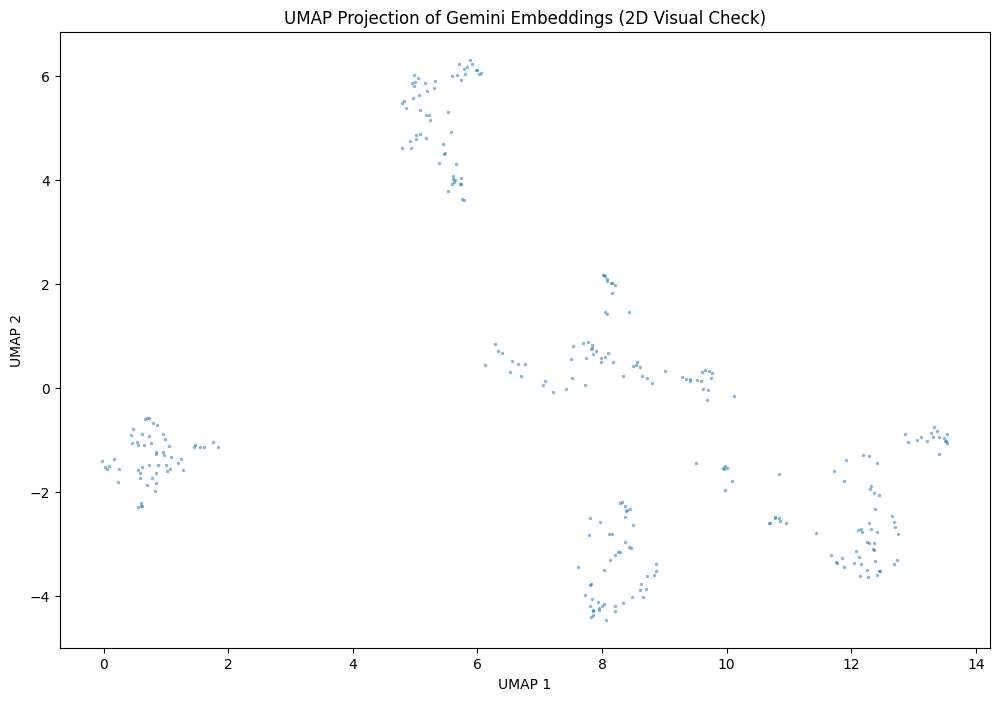

In [13]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reduce to 2D for visualization
# Note: Use 'cosine' because Gemini embeddings are angular-based
reducer_2d = umap.UMAP(
    n_neighbors=15, 
    n_components=2, 
    metric='cosine', 
    random_state=42
)

embeddings_2d = reducer_2d.fit_transform(np_embedding)

# 2. Create the plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=embeddings_2d[:, 0], 
    y=embeddings_2d[:, 1], 
    s=5,           # Small point size for dense data
    alpha=0.5,     # Transparency to see density
    edgecolor=None
)

plt.title('UMAP Projection of Gemini Embeddings (2D Visual Check)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

In [14]:
import umap

# 'embeddings' is your numpy array from Gemini
reducer = umap.UMAP(
    n_neighbors=15, 
    n_components=5,       # Reduce to 5 dimensions for clustering
    metric='cosine',      # Important: Gemini embeddings are cosine-based
    random_state=42
)

reduced_embeddings = reducer.fit_transform(np_embedding)

f:\ProgramData\miniconda3\envs\google-adk\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [15]:
reduced_embeddings

array([[ 7.5543776 ,  8.237355  ,  5.6947713 ,  2.4853866 ,  8.224391  ],
       [ 1.0421858 ,  6.3878603 ,  5.3740454 ,  7.9904222 ,  4.4005632 ],
       [-1.0715127 , 13.113004  ,  7.8159432 ,  5.820572  ,  2.2780976 ],
       ...,
       [ 1.0558783 ,  7.299548  ,  6.0215545 ,  6.9939065 ,  4.7795644 ],
       [-0.89195055, 11.672254  ,  8.122497  ,  6.2050204 ,  6.4747796 ],
       [ 7.459933  ,  8.01558   ,  5.511268  ,  3.0230887 ,  7.9412575 ]],
      shape=(303, 5), dtype=float32)

# Clustering HDBSCAN

In [16]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,   # Smallest grouping you'd consider a "topic"
    min_samples=1,         # Lower values make it less conservative/picky
    metric='euclidean',    # Standard for UMAP-reduced space
    prediction_data=True   # Allows assigning new points later
)

cluster_labels = clusterer.fit_predict(reduced_embeddings)

In [17]:

# Add cluster labels to your DataFrame
df['cluster'] = cluster_labels


In [18]:
df['cluster'].value_counts()

cluster
 0     56
 3     44
-1     33
 6     25
 11    24
 4     21
 5     18
 9     17
 2     16
 10    14
 1     13
 7     12
 8     10
Name: count, dtype: int64

# Keyword Extraction

In [23]:
def cluster_keywords_keybert(
    df: pd.DataFrame,
    *,
    doc_col: str = "document",
    cluster_col: str = "cluster",
    model_path: str | Path | None = None,
    top_n: int = 20,
    keyphrase_ngram_range: tuple[int, int] = (1, 3),
    stop_words: str | None = "english",
    max_cluster_chars: int = 12_000,
    join_sep: str = "\n\n",
    embed_batch_size: int = 16,
) -> pd.DataFrame:
    """Per cluster: merge texts, run KeyBERT with local Qwen3 (transformers), return long-form summary.

    Columns: ``cluster``, ``keywords``, ``cosine_similarities``, ``weight`` (similarity / cluster sum).
    """
    if model_path is None:
        model_path = (Path.cwd().parent / "model" / "Qwen3-Embedding-8B").resolve()
    model_path = Path(model_path).expanduser().resolve()

    backend = Qwen3KeyBERTBackend(model_path, batch_size=embed_batch_size)
    kw_model = KeyBERT(model=backend)

    rows: list[dict] = []

    for cid in sorted(df[cluster_col].dropna().unique(), key=lambda x: (str(type(x)), str(x))):
        texts = df.loc[df[cluster_col] == cid, doc_col].dropna().astype(str).tolist()
        blob = join_sep.join(t for t in texts if t.strip())
        if len(blob) > max_cluster_chars:
            blob = blob[:max_cluster_chars]

        if not blob.strip():
            continue

        kws = kw_model.extract_keywords(
            blob,
            keyphrase_ngram_range=keyphrase_ngram_range,
            stop_words=stop_words,
            top_n=top_n,
        )

        for phrase, sim in kws:
            rows.append(
                {
                    "cluster": cid,
                    "keywords": str(phrase),
                    "cosine_similarities": float(sim),
                }
            )

    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(columns=["cluster", "keywords", "cosine_similarities", "weight"])

    def _weights(s: pd.Series) -> pd.Series:
        s = s.astype(float)
        tot = s.sum()
        if tot > 0:
            return s / tot
        return pd.Series(np.zeros(len(s)), index=s.index)

    out["weight"] = out.groupby("cluster", group_keys=False)["cosine_similarities"].apply(_weights)
    return out.reset_index(drop=True)


In [19]:
df.head()

,id,document,embedding,meta_submission_type,meta_ticket_number,meta_language,meta_channel,meta_subject,meta_assigned_queue,meta_customer_ref,meta_status,meta_record_type,meta_created_at,meta_generator_version,meta_model,meta_branch_code,meta_synthetic,meta_region,meta_has_attachments,meta_updated_at,meta_source_file,meta_product_bucket,cluster
0,BK-2025-00000077,I visited the BR-BALI-003 branch today and had...,"[-0.034575458616018295, 0.0003996578452643007,...",standard_feedback_form,BK-2025-00000077,en,branch_counter,Exceptional service at the counter today,,SYN-CUST-B02-U012-16347958,resolved,bank_complaint_raw,2025-01-01T00:02:30+07:00,0.1.0,gemini-flash-lite-latest,BR-BALI-003,True,BALI_NUSA,False,2025-01-01T19:47:48+07:00,BR-BALI-003.jsonl,account,0
1,BK-2025-00000078,I am having persistent trouble logging into th...,"[0.0008665235945954919, 0.026163926348090172, ...",standard_feedback_form,BK-2025-00000078,en,mobile_app,Mobile app login issues,RETAIL_CARE,SYN-CUST-B02-U027-D8C772B1,closed,bank_complaint_raw,2025-01-01T22:40:09+07:00,0.1.0,gemini-flash-lite-latest,BR-BALI-003,True,BALI_NUSA,False,2025-01-01T23:40:30+07:00,BR-BALI-003.jsonl,digital_channel,5
2,BK-2025-00000079,I am writing to express my disappointment rega...,"[0.003141724970191717, 0.01029475498944521, -0...",standard_feedback_form,BK-2025-00000079,en,internet_banking,Dissatisfaction with account maintenance fees,RETAIL_CARE,SYN-CUST-B02-U007-3BEED8D1,open,bank_complaint_raw,2025-01-01T15:57:04+07:00,0.1.0,gemini-flash-lite-latest,BR-BALI-003,True,BALI_NUSA,False,2025-01-01T20:21:47+07:00,BR-BALI-003.jsonl,fees,3
3,BK-2025-00000080,I recently visited the BR-BALI-003 branch to i...,"[-0.006910950876772404, -0.010184208862483501,...",standard_feedback_form,BK-2025-00000080,en,branch_counter,Inquiry about mortgage interest rates,BRANCH_INTAKE,SYN-CUST-B02-U034-AB70C52B,resolved,bank_complaint_raw,2025-01-01T11:18:50+07:00,0.1.0,gemini-flash-lite-latest,BR-BALI-003,True,BALI_NUSA,False,2025-01-01T21:22:02+07:00,BR-BALI-003.jsonl,mortgage,-1
4,BK-2025-00000081,I am writing to formally lodge a complaint reg...,"[-0.00585011625662446, 0.01476304791867733, -0...",detailed_complaint_ticket,BK-2025-00000081,en,email,Unauthorized transaction dispute,BACK_OFFICE,SYN-CUST-B02-U014-8DF18393,resolved,bank_complaint_raw,2025-01-01T04:16:36+07:00,0.1.0,gemini-flash-lite-latest,BR-BALI-003,True,BALI_NUSA,True,2025-01-01T09:52:57+07:00,BR-BALI-003.jsonl,card,2


In [24]:
# Re-run the cell that defines Qwen3KeyBERTBackend + cluster_keywords_keybert if the kernel was reset.
summary_df = cluster_keywords_keybert(df)  # default: ../model/Qwen3-Embedding-8B from notebook cwd
# summary_df = cluster_keywords_keybert(
#     df,
#     model_path=r"F:\datascience\dsa-agent\vector-db-writer\model\Qwen3-Embedding-8B",
#     embed_batch_size=8,
#     top_n=15,
# )


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5059.11it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ValueError: Modality 'audio' is not supported by this SentenceTransformer model. Supported modalities: text